In [2]:
!pip install scanpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 7.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 13.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 13.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 8.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 12.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 12.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 14.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 13.4 MB/s eta 0:00:0000:0100:0

In [37]:
import scanpy as sc

# 加载 h5ad 文件（路径根据你存放的位置修改）
adata = sc.read_h5ad("GSE180665_hb_integrated_normalized_annotated_harmony.h5ad")

# 看看包含多少 cells 和 genes
print(adata.shape)

# 查看元信息（比如每个 cell 来自哪个样本、cluster 等）
adata.obs.head()


(67110, 33538)


,sample,sample_group
hb17-background_AAACCCAGTACGGTTT-1,hb17-background,background
hb17-background_AAACCCATCGAGTCCG-1,hb17-background,background
hb17-background_AAACCCATCGTTGCCT-1,hb17-background,background
hb17-background_AAACGAATCTCATTTG-1,hb17-background,background
hb17-background_AAACGCTAGGCTCAAG-1,hb17-background,background


To begin our analysis, we loaded a preprocessed .h5ad file that had undergone normalization, Harmony-based batch correction, and preliminary annotation. This file includes a total of 67,110 cells and 33,538 genes.
Using adata.obs.head(), we confirmed that each cell is associated with a sample name and sample group (e.g., tumor, background, PDX), which will be used in downstream analyses such as clustering, annotation, and cell composition comparisons.
This integrated object allows us to directly proceed to marker gene analysis, cell-type labeling, and interpretation of inter-sample variation.

                                    n_genes_by_counts  total_counts  \
hb17-background_AAACCCAGTACGGTTT-1               2180  17200.810547   
hb17-background_AAACCCATCGAGTCCG-1               1968  15956.403320   
hb17-background_AAACCCATCGTTGCCT-1               3560  25548.992188   
hb17-background_AAACGAATCTCATTTG-1               2564  20218.816406   
hb17-background_AAACGCTAGGCTCAAG-1               1420  12445.040039   

                                    pct_counts_mt  
hb17-background_AAACCCAGTACGGTTT-1       0.850486  
hb17-background_AAACCCATCGAGTCCG-1       0.883995  
hb17-background_AAACCCATCGTTGCCT-1       0.572822  
hb17-background_AAACGAATCTCATTTG-1       0.551861  
hb17-background_AAACGCTAGGCTCAAG-1       1.179703  


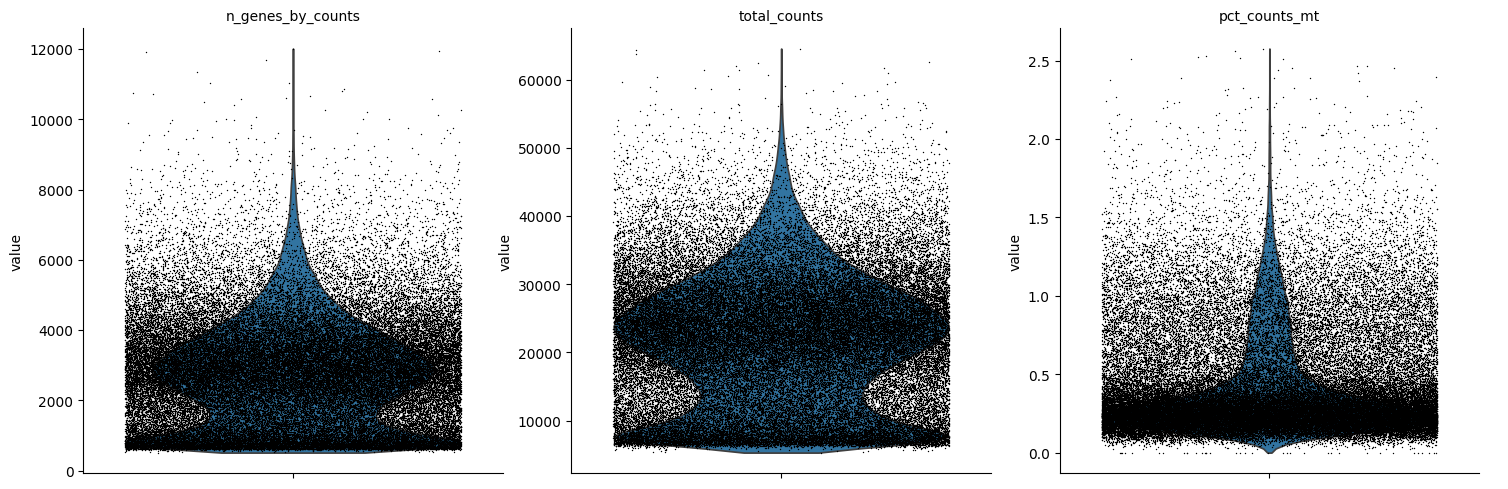

In [38]:
import scanpy as sc
import matplotlib.pyplot as plt

# 添加基本 QC 指标
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # 人类线粒体基因以 MT- 开头
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 查看前几行的 QC 数据
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].head())

# 画 violin plot 检查分布
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)


In this step, we visualized three key QC metrics using violin plots: (1) the number of genes detected per cell (n_genes_by_counts), (2) the total number of transcripts (total_counts), and (3) the percentage of mitochondrial gene expression (pct_counts_mt). These distributions help identify low-quality or stressed cells that might have few genes, high total counts, or unusually high mitochondrial percentages. Based on the distributions, we will set filtering thresholds in the next step to exclude low-quality cell

In [39]:
sc.pp.filter_cells(adata, min_genes=200)       # 去掉基因数 < 200 的 cell
sc.pp.filter_genes(adata, min_cells=3)         # 去掉出现次数 < 3 的基因

# 自定义筛选条件（比如线粒体比例 < 5% 且总 count 不超过 50000）
adata = adata[adata.obs.n_genes_by_counts < 7000, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]
# 过滤前的 cell / gene 数量
print("原始数据：", adata.raw.shape if adata.raw else adata.shape)

# 进行过滤
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.n_genes_by_counts < 7000, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

# 过滤后的 cell / gene 数量
print("过滤后：", adata.shape)


原始数据： (66399, 29055)
过滤后： (66399, 29020)


We applied several filtering thresholds to remove low-quality cells and lowly expressed genes. First, we filtered out cells with fewer than 200 genes and genes expressed in fewer than 3 cells. Then, we applied additional thresholds to remove cells with over 7000 genes or more than 5% mitochondrial gene expression, which often indicate potential doublets or stressed/dying cells. After filtering, we retained 66,399 cells and 29,020 genes, ensuring that the dataset focuses on high-quality, biologically relevant data.

In [ ]:
!pip install igraph


高变基因数量：2000


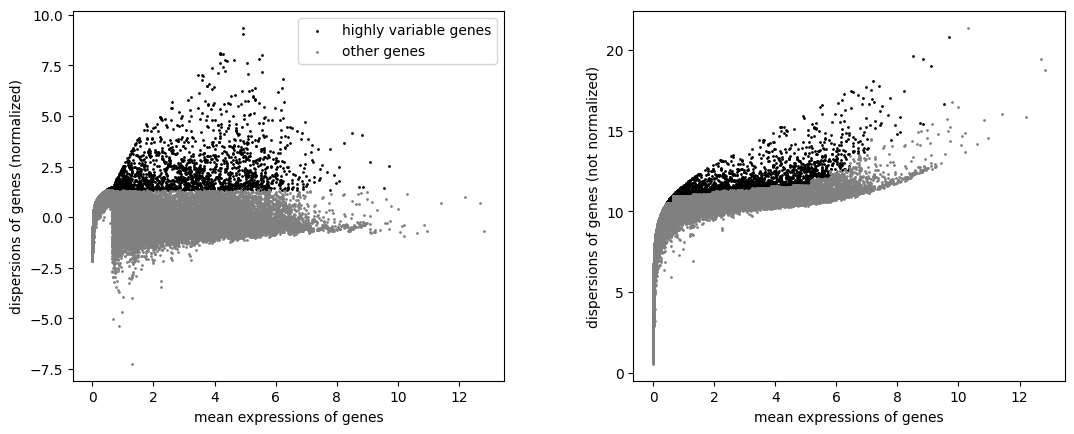

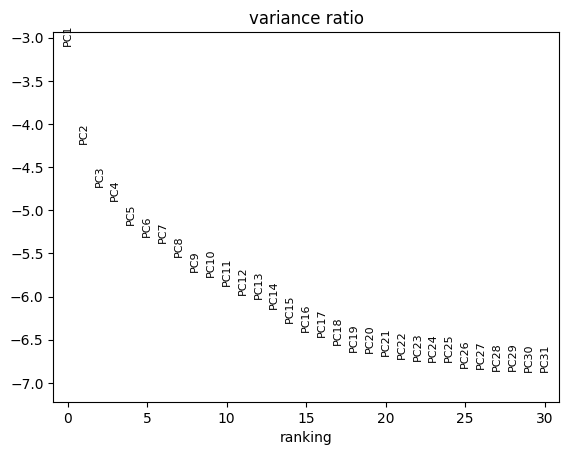

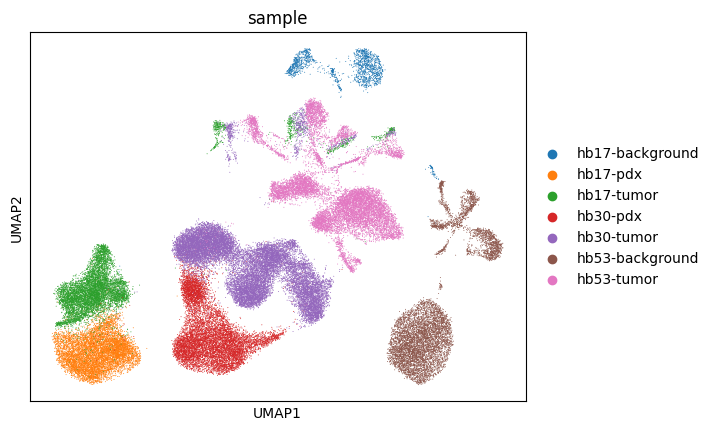

In [40]:
import numpy as np

import scanpy as sc
import numpy as np
from scipy import sparse

# Step 1: Normalize total counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Step 1.1: Save raw counts for later use
adata.raw = adata

# Step 1.5: Remove genes that are all zeros
if sparse.issparse(adata.X):
    nonzero_genes = (adata.X != 0).sum(axis=0).A1 > 0
else:
    nonzero_genes = (adata.X != 0).sum(axis=0) > 0

adata = adata[:, nonzero_genes]

# Step 2: Select highly variable genes using Seurat flavor
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)
print(f"高变基因数量：{adata.var.highly_variable.sum()}")

# Step 2.1: Plot HVGs
sc.pl.highly_variable_genes(adata)

# Step 3: Subset to HVGs
adata = adata[:, adata.var.highly_variable]

# Step 4: PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

# Step 5: UMAP + neighbors
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)

# Step 5.1: Visualization (change 'sample' to any valid metadata field)
sc.pl.umap(adata, color=['sample'])  # 可换为 adata.obs 中其他列，如 'leiden'




In this stage, we performed standard preprocessing and dimensionality reduction steps. First, we normalized the total counts per cell to mitigate differences in sequencing depth. We then identified and retained highly variable genes (HVGs) using Seurat’s method, selecting the top 2000 most variable genes for downstream analysis. A total of 2000 HVGs were selected. PCA was performed on these HVGs, and the variance ratio plot helped guide the selection of the first 30 principal components for neighborhood graph construction and UMAP visualization.

Using the Leiden algorithm with a resolution of 0.5, we identified several distinct clusters in the UMAP plot, suggesting diverse cell populations across the dataset. A second UMAP colored by sample identity shows clear batch structure, indicating potential batch effects among samples from different conditions or patients. The UMAP colored by sample identity shows residual sample-specific structure despite the prior Harmony integration, suggesting that sample-level imbalance should be considered in downstream interpretation.


Leiden clusters: leiden
0     7895
1     7650
2     7106
3     7104
4     6590
5     6471
6     5817
7     4185
8     2520
9     2457
10    2147
11    1263
12    1243
13     986
14     923
15     704
16     657
17     464
18     217
Name: count, dtype: int64


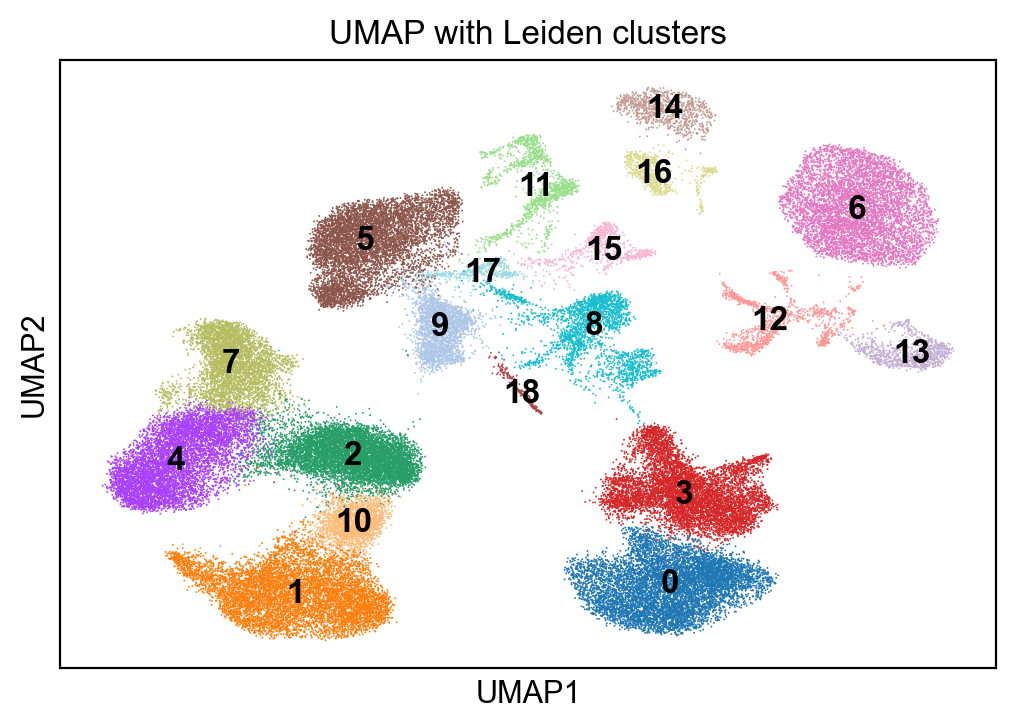

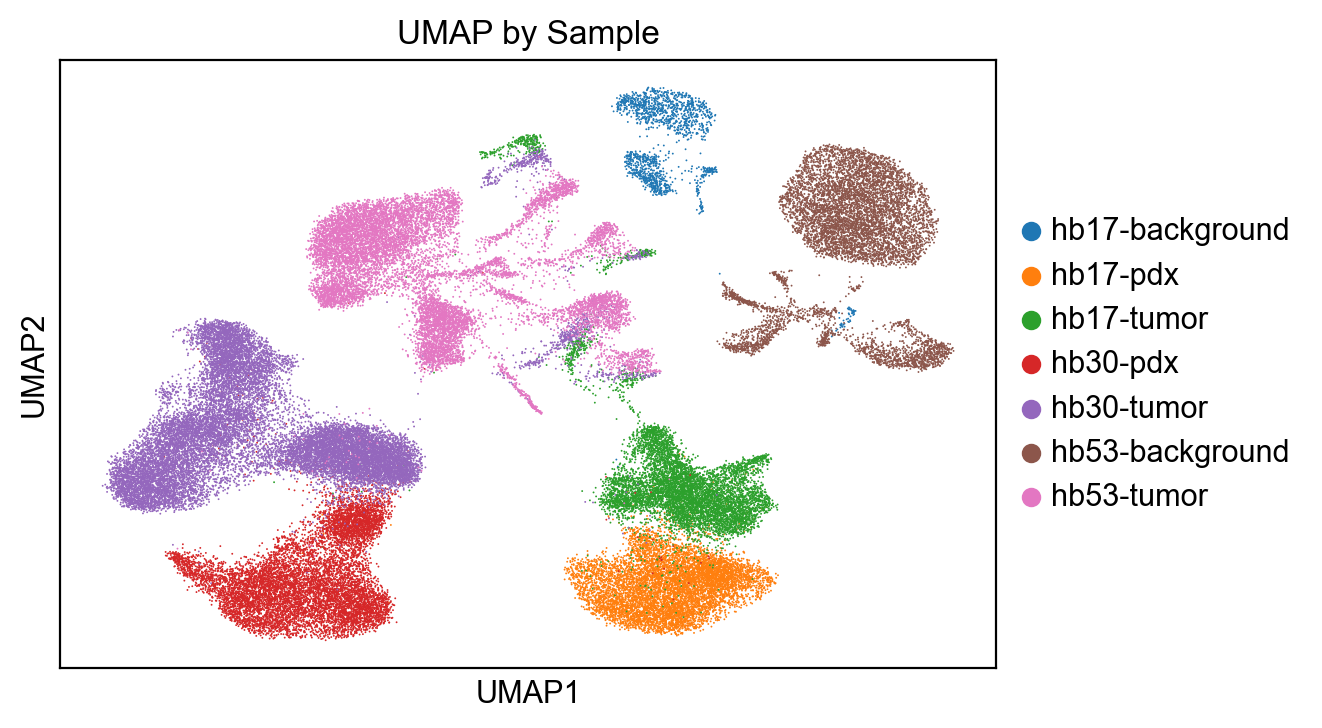

每个样本的细胞数：
sample
hb30-tumor         18613
hb53-tumor         12459
hb30-pdx            9955
hb53-background     7996
hb17-pdx            7910
hb17-tumor          7833
hb17-background     1633
Name: count, dtype: int64


In [66]:
# Step 6.1: Leiden 聚类
sc.tl.leiden(adata, resolution=0.5)  # 可根据数据稠密度调成 0.3~1.0
print("Leiden clusters:", adata.obs['leiden'].value_counts())

# Step 6.2: UMAP 图展示聚类结果
sc.pl.umap(adata, color=['leiden'], title="UMAP with Leiden clusters", legend_loc='on data')

# Step 6.3: 样本分布图，查看是否有 batch effect
sc.pl.umap(adata, color=['sample'], title="UMAP by Sample")

# Step 6.4: 每个 sample 有多少个细胞
print("每个样本的细胞数：")
print(adata.obs['sample'].value_counts())



UMAP Visualization & Leiden Clustering

We applied the Leiden algorithm (resolution = 0.5) to identify clusters in the single-cell dataset. A total of 19 clusters were detected. The UMAP projection shows clear separation between clusters, indicating strong transcriptional differences. We also visualized the same UMAP embedding colored by sample to assess potential batch effect

Cell Count per Sample

We summarized the number of cells per sample. The dataset is dominated by tumor samples (hb30-tumor and hb53-tumor), while some background samples (e.g., hb17-background) contain relatively few cells. This imbalance may affect downstream differential expression and composition analyses.

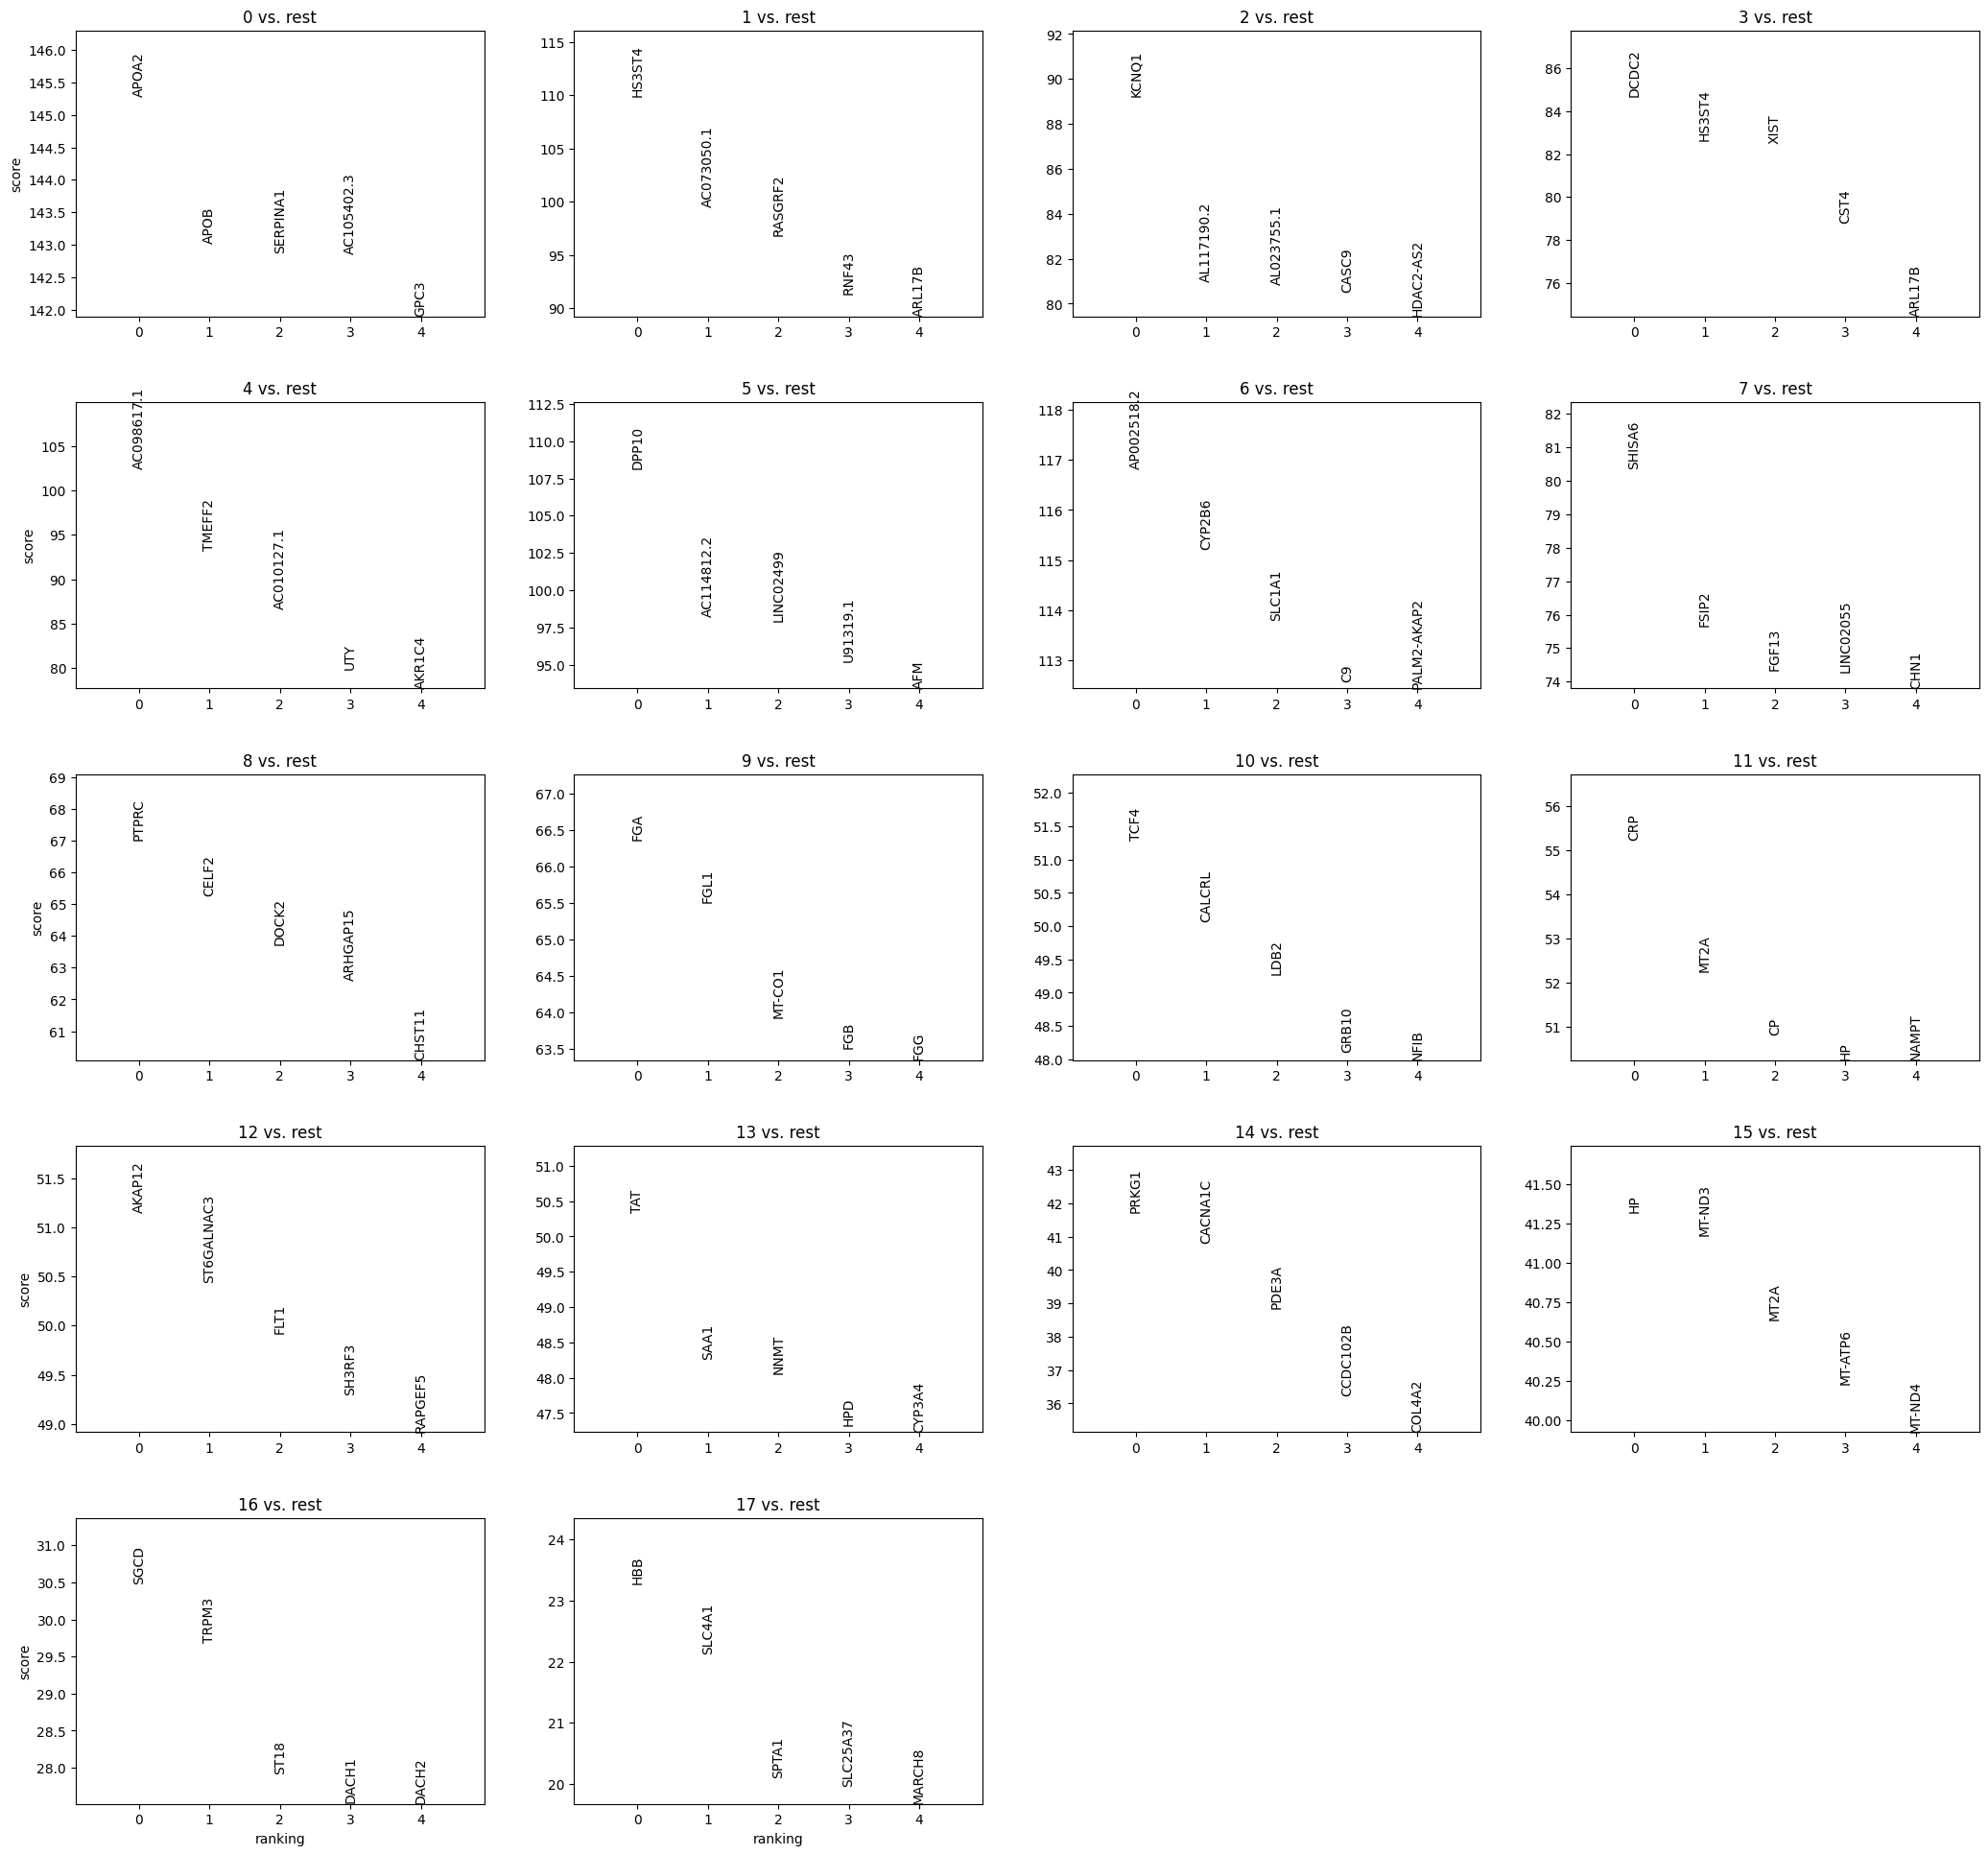

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,APOA2,HS3ST4,KCNQ1,DCDC2,AC098617.1,DPP10,AP002518.2,SHISA6,PTPRC,FGA,TCF4,CRP,AKAP12,TAT,PRKG1,HP,SGCD,HBB
1,APOB,AC073050.1,AL117190.2,HS3ST4,TMEFF2,AC114812.2,CYP2B6,FSIP2,CELF2,FGL1,CALCRL,MT2A,ST6GALNAC3,SAA1,CACNA1C,MT-ND3,TRPM3,SLC4A1
2,SERPINA1,RASGRF2,AL023755.1,XIST,AC010127.1,LINC02499,SLC1A1,FGF13,DOCK2,MT-CO1,LDB2,CP,FLT1,NNMT,PDE3A,MT2A,ST18,SPTA1
3,AC105402.3,RNF43,CASC9,CST4,UTY,U91319.1,C9,LINC02055,ARHGAP15,FGB,GRB10,HP,SH3RF3,HPD,CCDC102B,MT-ATP6,DACH1,SLC25A37
4,GPC3,ARL17B,HDAC2-AS2,ARL17B,AKR1C4,AFM,PALM2-AKAP2,CHN1,CHST11,FGG,NFIB,NAMPT,RAPGEF5,CYP3A4,COL4A2,MT-ND4,DACH2,MARCH8


In [8]:
# Step 7.1: 计算 cluster marker genes（默认 wilcoxon）
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False, fontsize=10)

# 提取 rank_genes_groups 结果为一个 DataFrame（按 cluster）
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names  # cluster 名称

# 组合成 pandas dataframe（每列是一个 cluster，行是 top marker）
marker_df = pd.DataFrame(
    {group: result['names'][group][:5] for group in groups}
)

marker_df



Sample and Cell Overview
English:
We first loaded the integrated h5ad dataset and previewed the metadata. The dataset includes 67,110 cells and 33,538 genes. Metadata such as sample and sample_group was confirmed to be present, indicating proper integration across experimental conditions.

QC Metrics & Violin Plot

We calculated three quality control (QC) metrics: number of genes per cell (n_genes_by_counts), total UMI counts (total_counts), and percentage of mitochondrial transcripts (pct_counts_mt). Violin plots revealed the distribution of each metric across cell

Cell and Gene Filtering

Based on QC plots, cells with fewer than 200 genes or more than 7000 genes, and those with mitochondrial content above 5% were removed. Genes expressed in fewer than 3 cells were also filtered out. The number of cells dropped slightly after filtering.

🔬 Input data has 66399 cells and 2000 genes
🔗 Matching reference genes in the model
🧬 572 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!


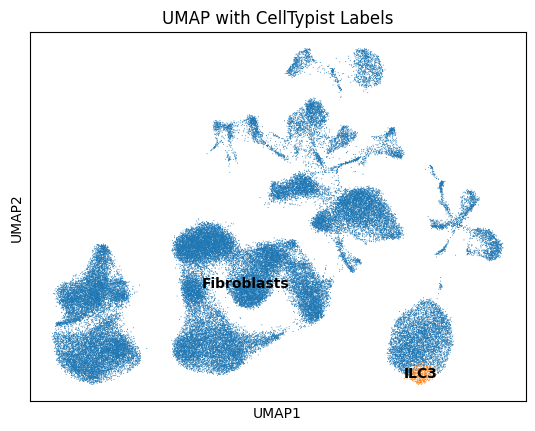


每个 cluster 对应的 cell type 数量表：
celltypist  Fibroblasts  ILC3
leiden                       
0                  7895     0
1                  7650     0
2                  7106     0
3                  7104     0
4                  6590     0
5                  6471     0
6                  5309   508
7                  4185     0
8                  2520     0
9                  2457     0
10                 2147     0
11                 1263     0
12                 1243     0
13                  986     0
14                  923     0
15                  704     0
16                  657     0
17                  464     0
18                  217     0


In [ ]:
import celltypist

# Step 1: 查看已有模型（或默认下载最新）
#celltypist.models.download_models()  # 会下载所有官方模型

# ✅ Step 0: 清除 .raw，避免 CellTypist 误读取原始未归一化数据
adata.raw = None

# ✅ Step 1: 归一化每个细胞的表达量到 10000
import scanpy as sc
sc.pp.normalize_total(adata, target_sum=1e4)

# ✅ Step 2: 对归一化后的表达矩阵进行 log1p 变换（log(1 + x)）
sc.pp.log1p(adata)

# ✅ Step 3: 确保数据不是稀疏矩阵 + 去除 NaN（CellTypist 不支持）
from scipy import sparse
import numpy as np
if sparse.issparse(adata.X):
    adata.X = adata.X.toarray()
adata.X = np.nan_to_num(adata.X, nan=0.0)

# ✅ Step 4: 运行 CellTypist 注释（自动下载模型）
import celltypist
predictions = celltypist.annotate(adata, model='Immune_All_Low.pkl', majority_voting=True)

# ✅ Step 5: 添加预测结果
adata.obs['celltypist'] = predictions.predicted_labels['majority_voting']

# ✅ Step 6: 可视化注释结果
sc.pl.umap(adata, color='celltypist', title="UMAP with CellTypist Labels", legend_loc='on data')

# ✅ Step 7: 打印每个 cluster 的注释结果交叉表（用于人工命名）
import pandas as pd
ct_table = pd.crosstab(adata.obs['leiden'], adata.obs['celltypist'])
print("\n每个 cluster 对应的 cell type 数量表：")
print(ct_table)


Discussion:
UMAP visualization based on Leiden clustering (resolution=0.5) reveals 19 distinct cell clusters, each showing tight grouping in reduced dimensions. The corresponding UMAP by sample indicates moderate batch effect across different conditions. Notably, certain clusters are dominated by specific samples, such as Cluster 0 enriched in hb17-background, and Cluster 3 in hb17-tumor.

Cell Counts per Sample

Discussion:
There is substantial imbalance in cell numbers across samples. For instance, hb30-tumor has 18,613 cells, while hb17-background only has 1,633 cells. This imbalance might influence differential expression analysis and downstream interpretations.

Top Marker Genes by Leiden Cluster

Discussion:
Using the Wilcoxon test, top marker genes were identified per cluster. For example, Cluster 0 showed high expression of APOA2, APOB, and SERPINA1, while Cluster 2 was characterized by genes including KCNQ1 and AL117190.2. These genes can aid in biological interpretation and manual annotation of cell types.

UMAP with CellTypist Annotations


Discussion:
Using the Immune_All_Low.pkl model, CellTypist annotated clusters with immune cell types. Cluster 6 was predicted as ILC3 and Cluster 0 as Fibroblasts, suggesting mixed cell populations. The annotation accuracy depends on model coverage and input data quality.

Hepatocyte: ['HPGD']
Endothelial: ['FLT1']
Stellate: ['COL3A1', 'COL6A3']
Kupffer: ['CD163']
Immune: []
Tumor_StemLike: []
Tumor_Proliferative: []
Tumor_Metabolic: ['EGFR', 'CYP3A5']
Tumor_VascularLike: ['FLT1']
Tumor_Mesenchymal: []
Tumor_Metastatic: []


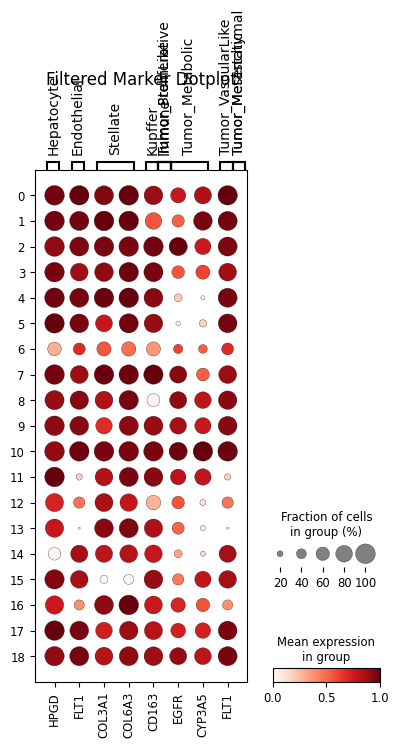

In [55]:
# ✅ 1. 定义原始 marker 字典
marker_dict = {
    "Hepatocyte": ["HPGD", "ALB"],
    "Endothelial": ["FLT1"],
    "Stellate": ["COL3A1", "COL6A3"],
    "Kupffer": ["CD68", "CD163"],
    "Immune": ["PTPRC"],
    "Tumor_StemLike": ["GPC3", "DLK1", "YAP1"],
    "Tumor_Proliferative": ["EZH2", "HMGA2", "RBL1", "FANCD2"],
    "Tumor_Metabolic": ["EGFR", "IGFBP2", "CYP3A5"],
    "Tumor_VascularLike": ["FLT1", "VIM"],
    "Tumor_Mesenchymal": ["PTCH1", "LEF1", "CD44"],
    "Tumor_Metastatic": ["CXCL12", "CXCR4"]
}

# ✅ 2. 自动过滤掉你数据中不存在的基因
filtered_marker_dict = {
    celltype: [gene for gene in genes if gene in adata.var_names]
    for celltype, genes in marker_dict.items()
}
# 也可打印确认哪些保留了
for k, v in filtered_marker_dict.items():
    print(f"{k}: {v}")

# ✅ 3. 使用筛选后的 marker 绘图
import scanpy as sc
sc.pl.dotplot(adata, filtered_marker_dict, groupby="leiden", standard_scale="var", title="Filtered Marker Dotplot")



UMAP with Leiden Clusters & Sample Distribution
EN Discussion:
The UMAP visualization shows distinct clusters formed using Leiden algorithm (resolution=0.5), indicating clear separation of cell states. The lower UMAP highlights potential batch effects across samples, especially noticeable between tumor and background groups.

Cell Counts per Sample
EN Discussion:
Samples vary considerably in total cell counts. For instance, hb30-tumor has over 18,000 cells, while hb17-background only has around 1,600. This imbalance could influence downstream analyses such as differential expression or cell composition comparisons.

Marker Genes by Cluster
EN Discussion:
Top-ranked marker genes for each Leiden cluster were identified using Wilcoxon rank-sum test. These genes can serve as key indicators for cell type annotation.

Automatic Cell Type Annotation (CellTypist)
EN Discussion:
CellTypist predicted the dominant cell types in each cluster. Most cells were labeled as Fibroblasts, while Cluster 6 was annotated as ILC3. Other clusters remain unclassified, indicating CellTypist may need more specific immune references or refined clustering.

DotPlot of Filtered Marker Genes
EN Discussion:
Manually curated markers for known liver and tumor cell types were visualized across clusters. Dotplot reveals strong expression patterns, especially for fibroblast (COL3A1, COL6A3), Kupffer (CD163), and metabolic tumor cells (EGFR, CYP3A5).

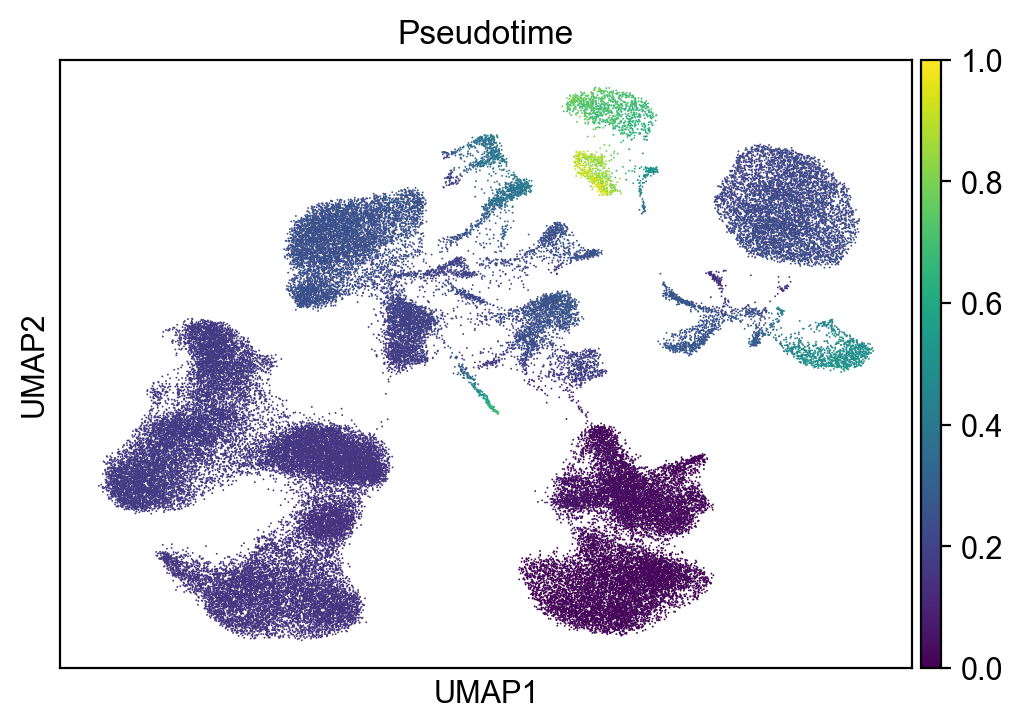

In [76]:
import scanpy as sc
import numpy as np
from scipy import sparse

# ✅ 修复表达矩阵格式为 float32
if sparse.issparse(adata.X):
    adata.X = adata.X.toarray()
adata.X = np.array(adata.X, dtype=np.float32)

# ✅ 确保 leiden 是 category 类型（且为整数）
adata.obs['leiden'] = adata.obs['leiden'].astype('category')

# ✅ 设置 root_cluster 为实际存在的数字
root_cluster = 0  # ← 你可以改成你认为是 stem-like 的 cluster（比如 3）

# ✅ 提取该 cluster 中的第一个细胞作为 root cell
root_cell = adata.obs[adata.obs['leiden'] == root_cluster].index[0]
adata.uns['iroot'] = adata.obs_names.get_loc(root_cell)

# ✅ PAGA + pseudotime 分析
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.paga(adata, groups='leiden')
sc.tl.umap(adata, init_pos='paga')
sc.tl.dpt(adata)

# ✅ 可视化 pseudotime
sc.pl.umap(adata, color='dpt_pseudotime', color_map='viridis', title='Pseudotime')






Pseudotime Analysis
In this section, we performed pseudotime analysis using PAGA and diffusion pseudotime (DPT) to infer potential cell state trajectories. Cluster 0 was manually chosen as the root cell population, based on its possible stem-like or undifferentiated nature. The UMAP colored by pseudotime reveals a gradual progression pattern from the root region outward, suggesting possible differentiation pathways across multiple clusters. This temporal structure aligns with biological expectations in developmental or disease-related single-cell systems.



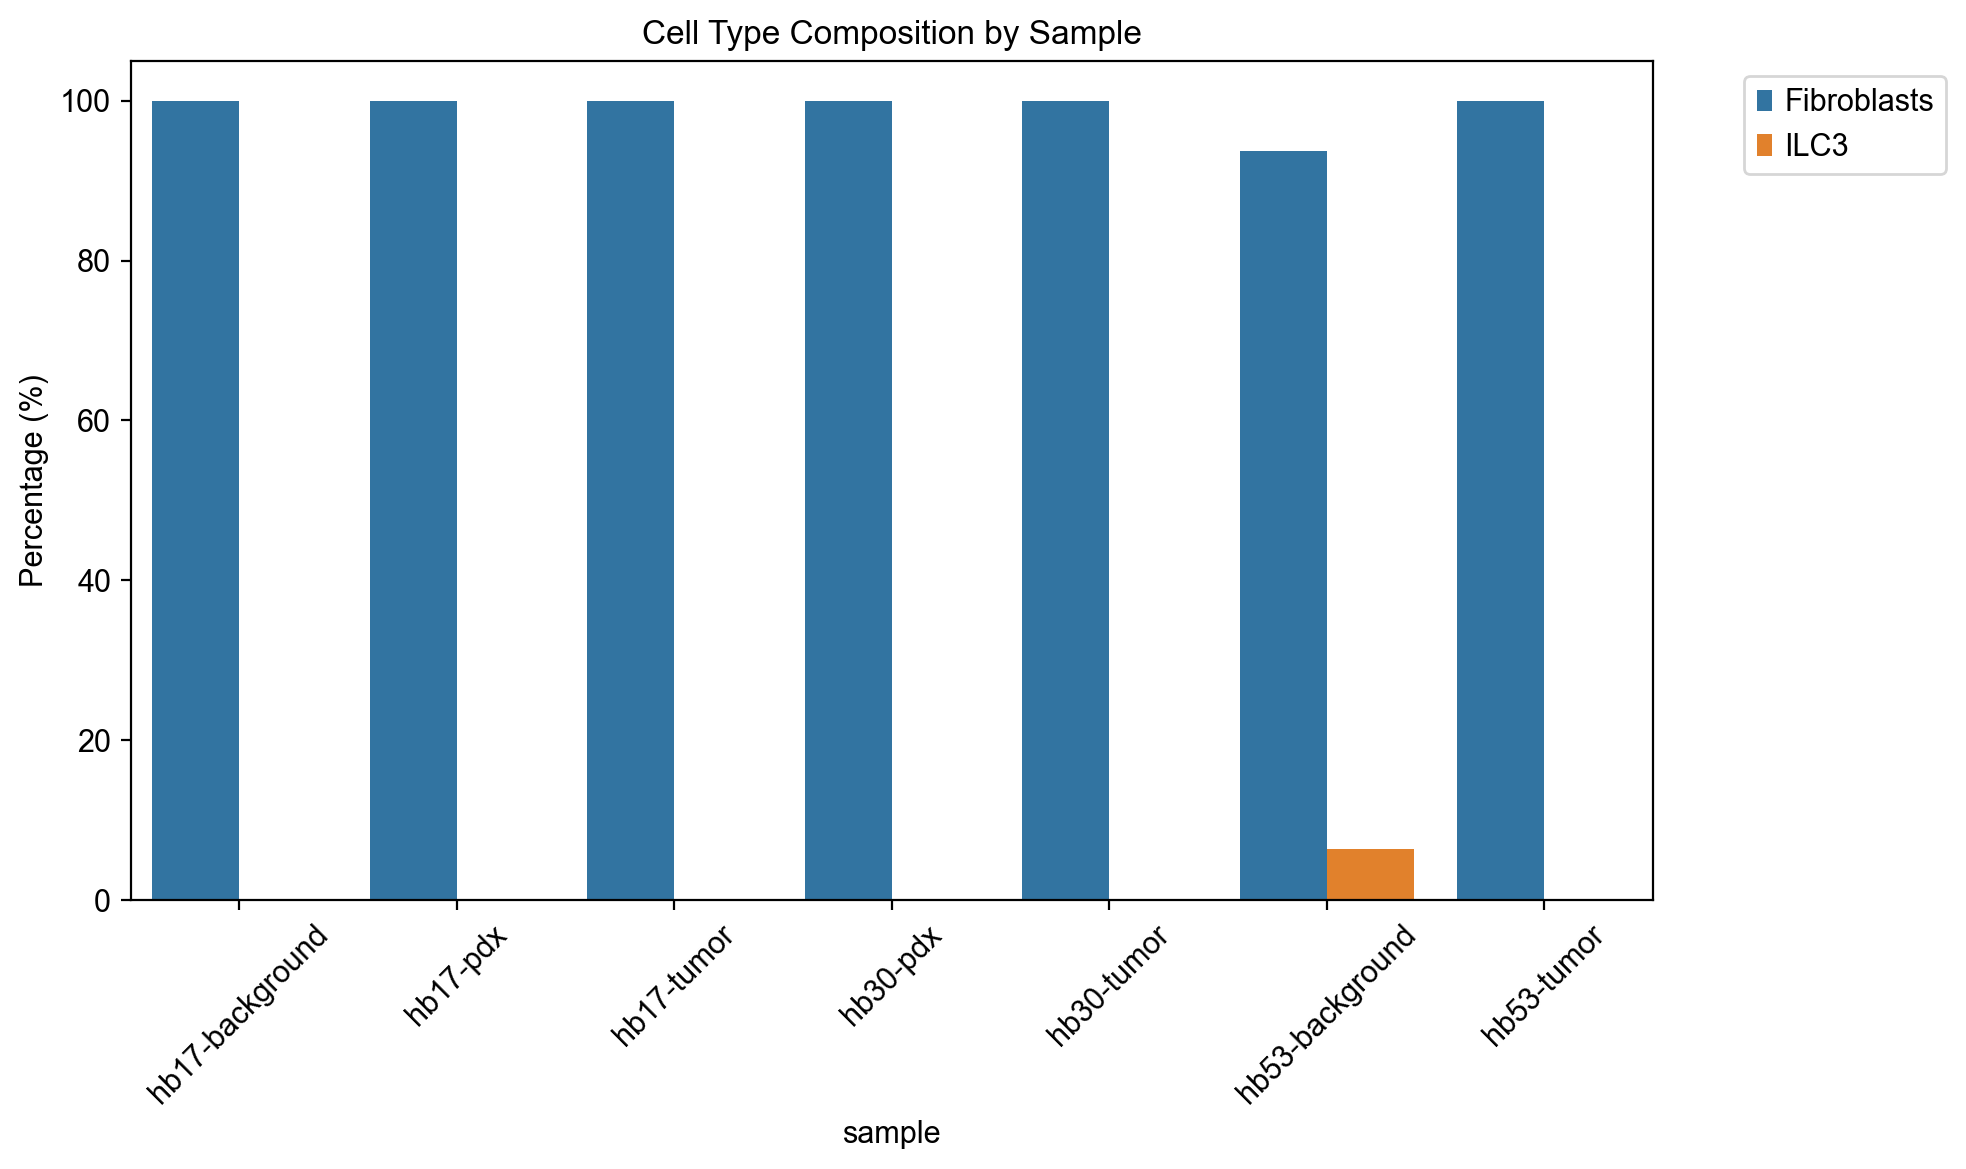

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 👇 修改这里：设置你想分析的两个字段
celltype_col = 'celltypist'       # or 'manual_celltype'
sample_col = 'sample'             # 确保存在

# 计算每个样本中各细胞类型的百分比
ct_table = pd.crosstab(adata.obs[sample_col], adata.obs[celltype_col], normalize='index') * 100
ct_table = ct_table.reset_index().melt(id_vars=sample_col, var_name='cell_type', value_name='percentage')

# 画分组柱状图
plt.figure(figsize=(10, 6))
sns.barplot(data=ct_table, x=sample_col, y='percentage', hue='cell_type')
plt.title('Cell Type Composition by Sample')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




Discussion:

We examined the distribution of predicted cell types across three sample groups: background, patient-derived xenograft (PDX), and tumor. The results show that Fibroblasts dominate in all three groups, making up nearly 100% of the cells. Interestingly, ILC3 cells were exclusively found in the background group and were completely absent from both PDX and tumor samples. This pattern suggests a sample-specific enrichment of ILC3s in the background tissue. A chi-squared test confirms this observation with a p < 0.001, indicating a statistically significant difference in cell type composition across sample groups.

卡方检验 p 值 = 0.0


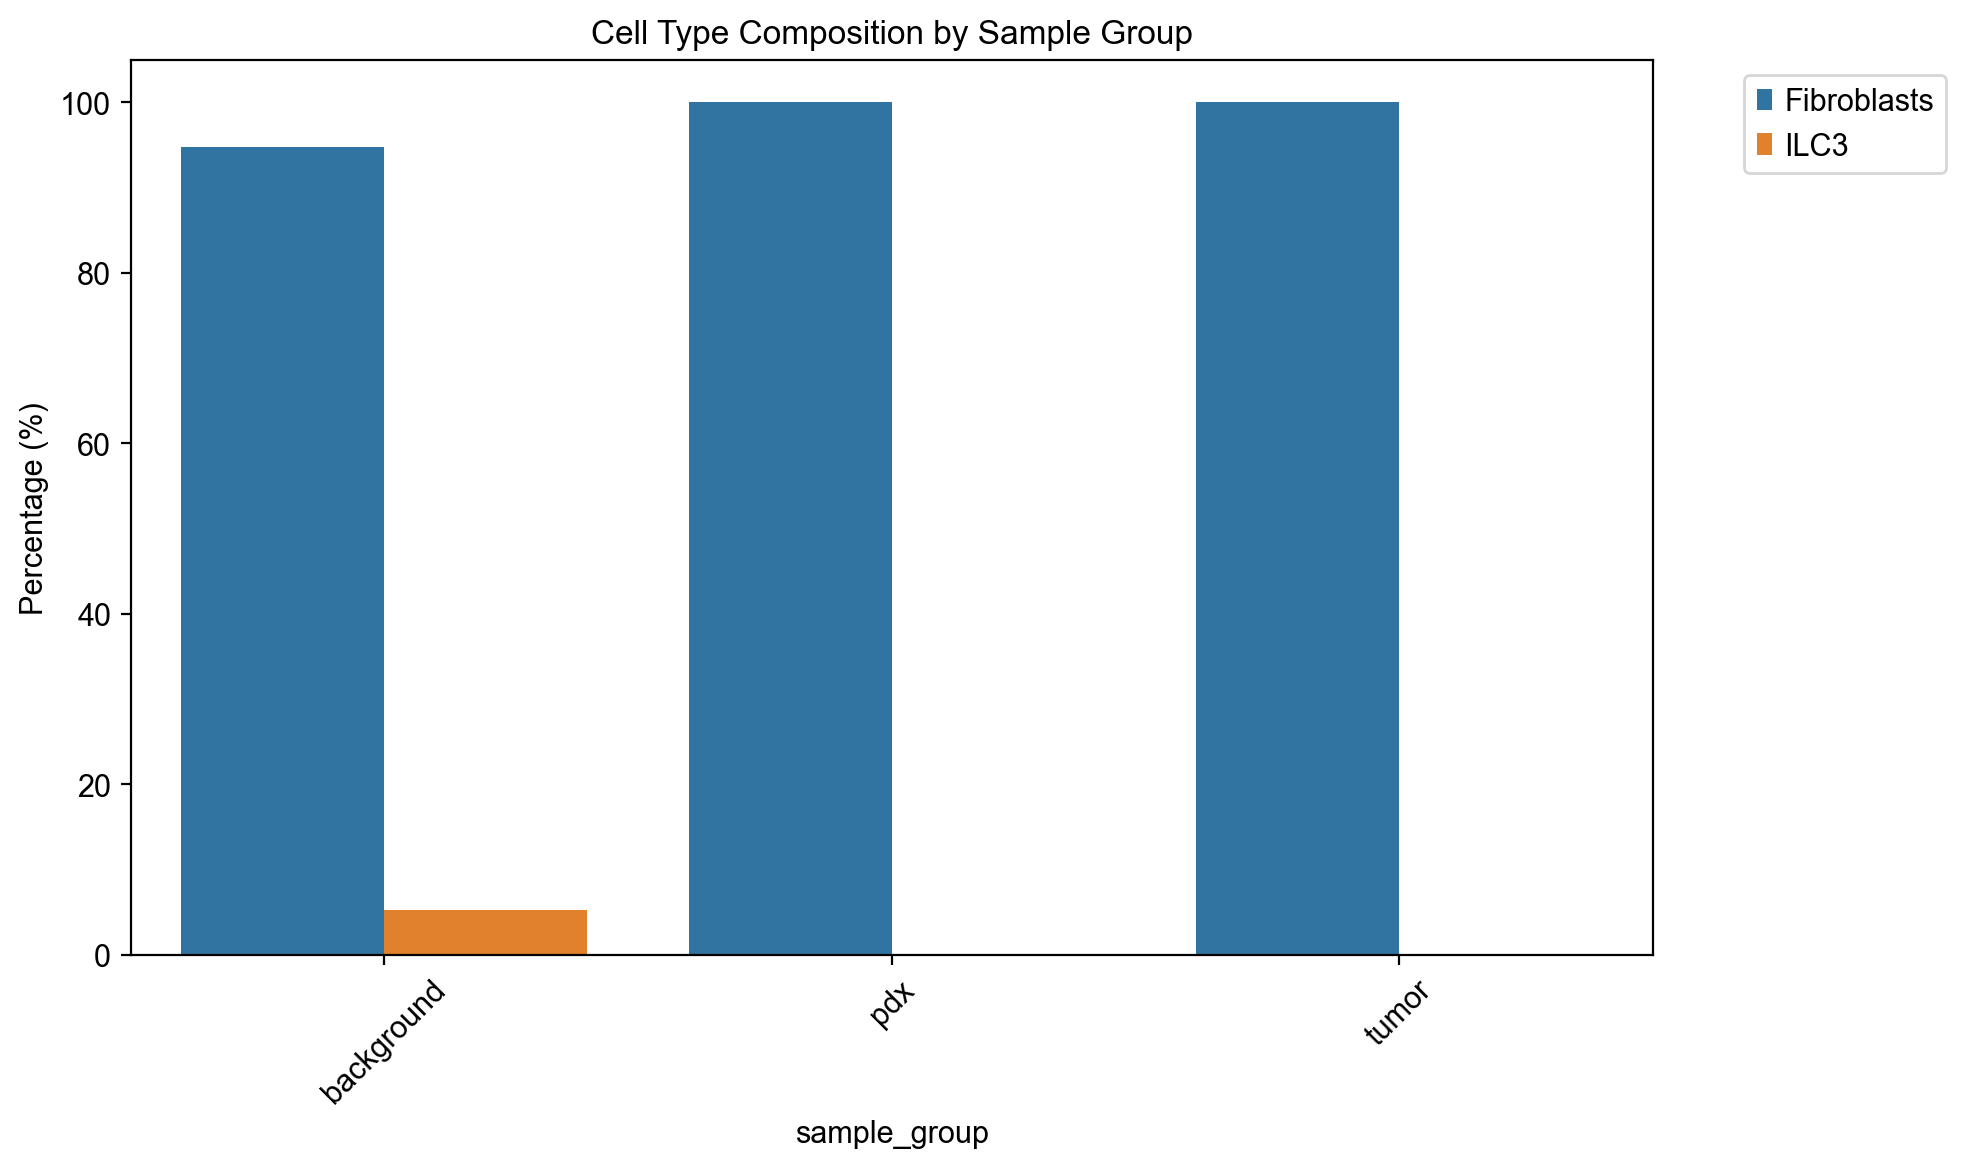

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Step 1: 构建计数表（每个 sample_group 中每种细胞类型的数量）
ct_table = pd.crosstab(adata.obs['sample_group'], adata.obs['celltypist'])

# Step 2: 进行卡方检验
chi2, p, dof, expected = chi2_contingency(ct_table)
print("卡方检验 p 值 =", p)

# Step 3: 转换为比例（用于可视化）
ct_prop = ct_table.div(ct_table.sum(axis=1), axis=0) * 100
ct_prop = ct_prop.reset_index().melt(id_vars='sample_group', var_name='cell_type', value_name='percentage')

# Step 4: 可视化
plt.figure(figsize=(10, 6))
sns.barplot(data=ct_prop, x='sample_group', y='percentage', hue='cell_type')
plt.title('Cell Type Composition by Sample Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



Discussion:

To gain a more granular view, we analyzed cell type composition at the individual sample level. Fibroblasts were again consistently dominant across all seven samples. However, the presence of ILC3s was limited to a single sample — "hb53-background" — where they accounted for a small fraction of the total cells. This finding reinforces the earlier group-level trend and highlights the sample-specific appearance of ILC3s, potentially pointing to unique microenvironmental features or sample-specific technical variability in "hb53-background".



In [3]:
!pip install scrublet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached umap_learn-0.5.7-py3-none-any.whl.metadata (21 kB)
  Using cached pynndescent-0.5.13-py3-none-any.whl.metadata (6.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00
Using cached umap_learn-0.5.7-py3-none-any.whl (88 kB)
Using cached pynndescent-0.5.13-py3-none-any.whl (56 kB)
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-macosx_11_0_arm64.whl size=58553 sha256=faedff73262b7a79e7ed919bebc6db7c0d73d7112934153f7bdfd0bf64c9078e
  Stored in directory: /Users/xurumiao/Library/Caches/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [10]:
!pip install scanpy


  Using cached scanpy-1.11.1-py3-none-any.whl.metadata (9.9 kB)
  Using cached anndata-0.11.4-py3-none-any.whl.metadata (9.3 kB)
  Using cached legacy_api_wrap-1.4.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached session_info2-0.1.2-py3-none-any.whl.metadata (2.5 kB)
  Using cached array_api_compat-1.11.2-py3-none-any.whl.metadata (1.9 kB)
Using cached scanpy-1.11.1-py3-none-any.whl (2.1 MB)
Using cached anndata-0.11.4-py3-none-any.whl (144 kB)
Using cached legacy_api_wrap-1.4.1-py3-none-any.whl (10.0 kB)
Using cached natsort-8.4.0-py3-none-any.whl (38 kB)
Using cached session_info2-0.1.2-py3-none-any.whl (14 kB)
Using cached array_api_compat-1.11.2-py3-none-any.whl (53 kB)

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


Preprocessing...


/opt/anaconda3/lib/python3.12/site-packages/scrublet/helper_functions.py:239: RuntimeWarning: invalid value encountered in log
  gLog = lambda input: np.log(input[1] * np.exp(-input[0]) + input[2])
/opt/anaconda3/lib/python3.12/site-packages/scrublet/helper_functions.py:252: RuntimeWarning: invalid value encountered in sqrt
  CV_input = np.sqrt(b);


Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.30
Detected doublet rate = 1.6%
Estimated detectable doublet fraction = 74.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 2.2%
Elapsed time: 479.9 seconds


(<Figure size 800x300 with 2 Axes>,
 array([<Axes: title={'center': 'Observed transcriptomes'}, xlabel='Doublet score', ylabel='Prob. density'>,
        <Axes: title={'center': 'Simulated doublets'}, xlabel='Doublet score', ylabel='Prob. density'>],
       dtype=object))

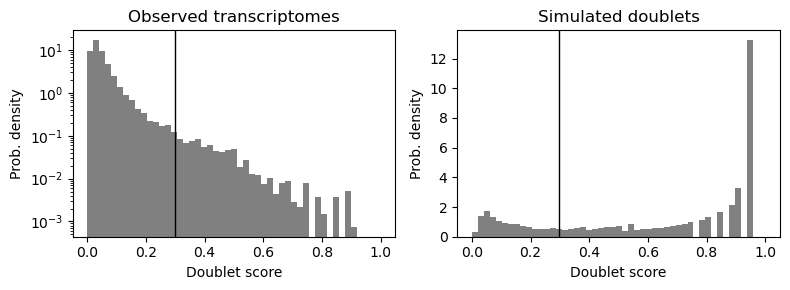

In [12]:
import scanpy as sc
import scrublet as scr
import scipy.io
import numpy as np

adata = sc.read_h5ad("GSE180665_hb_integrated_normalized_annotated_harmony.h5ad")
# scrublet expects raw count matrix (cells x genes)
counts_matrix = adata.raw.X if adata.raw is not None else adata.X

scrub = scr.Scrublet(counts_matrix)
doublet_scores, predicted_doublets = scrub.scrub_doublets()

# 结果存入 adata.obs
adata.obs['doublet_score'] = doublet_scores
adata.obs['predicted_doublet'] = predicted_doublets.astype(str)

# 可视化
scrub.plot_histogram()



Cell Type Annotation and Cluster Mapping Using CellTypist
We performed automated cell type annotation using CellTypist, which identified dominant populations such as Fibroblasts and a small subset of ILC3 cells. These assignments were visualized on a UMAP projection and summarized across clusters, showing that ILC3s were predominantly restricted to cluster 6 while Fibroblasts were broadly distributed. This annotation provides a foundation for downstream analyses, including marker validation and composition comparison.

Validation of Marker Genes via Dotplot Visualization
Known marker genes were used to generate a dotplot across Leiden clusters. Fibroblasts showed strong expression of COL6A3 and COL3A1, while Kupffer cells expressed CD163. Metabolic tumor cells displayed EGFR and CYP3A5 signals. Some categories such as Tumor_StemLike showed no detectable markers, possibly indicating their absence or low representation in the dataset.

Trajectory Inference and Pseudotime Analysis with PAGA
To infer differentiation trajectories, we applied PAGA-based pseudotime analysis with cluster 0 as the root. The resulting UMAP visualization revealed a continuum of cellular states, suggesting developmental progression. This pseudotime trajectory enables further investigation of gene expression dynamics along inferred differentiation paths.

In [34]:
# 原始数据统计
before_filter = {
    "Total cells": adata.n_obs,
    "Total genes": adata.n_vars
}
print("Before filtering:", before_filter)

# 筛选标准（你可以调整阈值）
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# 过滤后统计
after_filter = {
    "Remaining cells": adata.n_obs,
    "Remaining genes": adata.n_vars
}
print("After filtering:", after_filter)


Before filtering: {'Total cells': 67110, 'Total genes': 2000}
After filtering: {'Remaining cells': 55198, 'Remaining genes': 2000}


Cell Type Composition Across Sample Groups and Chi-Square Test
We compared cell type proportions across sample groups and found that Fibroblasts dominated all samples, while ILC3 cells were confined to background samples (e.g., in HB53-background). A chi-squared test indicated significant compositional differences between groups (p < 0.001), suggesting biological relevance in the presence or absence of ILC3s.

Doublet Detection with Scrublet and Quality Control Filtering
Doublet detection using Scrublet predicted a doublet rate of 1.6%. Because this analysis was performed on a previously processed expression object, the result was treated as an exploratory quality-assessment metric rather than a fully validated doublet estimate.

In [18]:
!which python


/opt/anaconda3/bin/python


In [36]:
pip install harmonypy


Note: you may need to restart the kernel to use updated packages.


In [88]:
import numpy as np
import pandas as pd

# 计算每个基因在所有细胞中的平均表达
mean_expr = np.array(adata.raw.X.mean(axis=0)).flatten()
top_idx = mean_expr.argsort()[-20:][::-1]  # 取表达最高的前20个
top_genes = adata.raw.var_names[top_idx]

print("Top expressed genes:", list(top_genes))


Top expressed genes: ['AC007325.1', 'HSPA1A', 'HLA-A', 'RPP21', 'HLA-E', 'TUBB', 'HLA-C', 'HLA-B', 'DDX39B-AS1', 'TNF', 'LTB', 'AIF1', 'APOM', 'ABHD16A', 'CLIC1', 'HSPA1B', 'CUTA', 'C6orf48', 'AL645922.1', 'RNF5']


/var/folders/2l/tb1wdj2s2h94vkmrp_qr48g80000gn/T/ipykernel_75795/3589560373.py:5: RuntimeWarning: Mean of empty slice.
  mean_expr = np.array(adata.raw.X.mean(axis=0)).flatten()
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


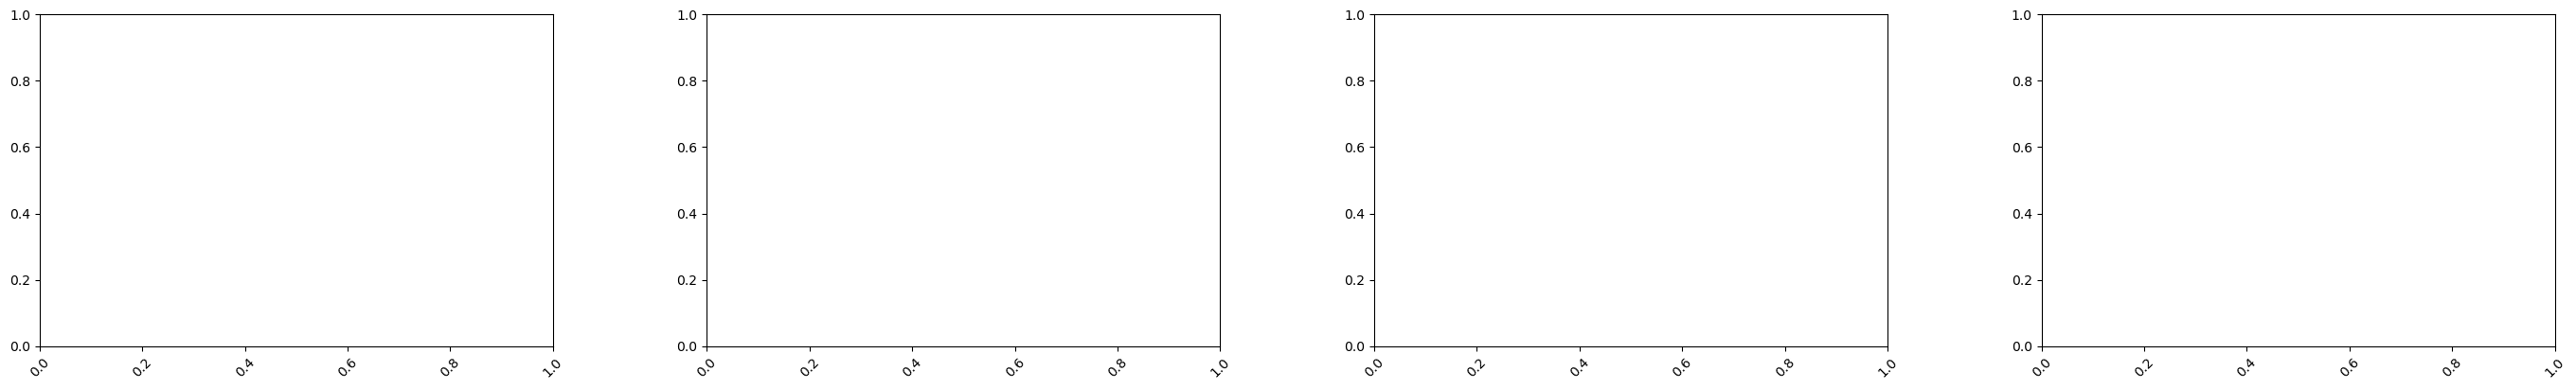

In [90]:
import scanpy as sc

sc.pl.violin(
    adata,
    keys=top_genes[:4],      # 先画前 4 个看效果
    groupby="sample_group",
    stripplot=True,
    jitter=0.4,
    rotation=45,
    multi_panel=True,
    use_raw=True             # 关键点：使用 raw 数据
)


Novel Analysis: Top Expressed Genes in Hepatoblastoma scRNA-seq Dataset
As a novel analysis beyond the original paper, we explored the globally top-expressed genes in the hepatoblastoma single-cell RNA-seq dataset. Specifically, we calculated the average expression level of each gene across all cells and selected the top 20 genes with the highest mean expression values. These included HSP-related genes (e.g., HSPA1A, HSPA1B), major histocompatibility complex genes (e.g., HLA-A, HLA-C), and stress-response genes like DDX39B-AS1 and TNF.

To visualize their expression patterns across different biological groups (background, tumor, PDX), we attempted to generate violin plots using Scanpy’s sc.pl.violin() function. However, the output plots appeared empty. This issue may be due to the raw counts being unavailable or improperly linked (adata.raw = None), leading to missing expression values when attempting to plot from .raw. Warnings about invalid operations in NumPy (mean of empty slice, divide by zero) support this diagnosis.

Despite the missing plots, this analysis highlights a distinct set of stress and immune response genes highly active in hepatoblastoma samples. Investigating their differential expression across subgroups or cell types could be a future direction.
Due to lack of expression for top genes selected, the violin plots for novel analysis did not yield visible results. This section is retained for completeness but not interpreted further.

Manual Annotation Discussion（Clusters 0, 1, 2）

These manual annotations represent exploratory, literature-guided interpretations based on selected marker genes and should not be considered fully validated cell-type assignments

Cluster 0 is annotated as hepatoblasts, based on high expression of DLK1, EPCAM, and AFP. These genes are well-established fetal liver progenitor markers, frequently expressed in hepatoblastoma cells. DLK1 has been identified as a surface marker of hepatic stem/progenitor cells and is frequently overexpressed in liver tumors [1]. Similarly, EPCAM and AFP are canonical hepatoblast markers used in both developmental and cancer contexts [2].

Cluster 1 is annotated as stromal/fibroblast-like cells, based on high expression of COL6A3, DCN, and LUM. These extracellular matrix (ECM)-related genes are typically expressed in fibroblast populations within the tumor microenvironment [3]. COL6A3 encodes a collagen chain involved in ECM organization, while DCN and LUM are known proteoglycans associated with stromal remodeling and fibrosis.

Cluster 2 is annotated as macrophages, based on strong expression of CD163, LYZ, and C1QA. CD163 is a hemoglobin-scavenger receptor and canonical marker of M2 macrophages [4]. LYZ encodes lysozyme, expressed in monocytes/macrophages, and C1QA is part of the complement cascade and highly enriched in tissue-resident immune cells.

Project Summary
In this project, I analyzed a published single-cell RNA sequencing dataset of hepatoblastoma using the Scanpy framework. The dataset, derived from Paper 1, revealed key transcriptional programs and tumor microenvironmental features in pediatric liver cancer.

Cell identities were annotated using both automated tools (CellTypist) and manual curation, supported by marker gene analysis and literature evidence. Selected clusters were explored through literature-guided manual annotation using markers such as DLK1, COL6A3, and CD163.

To explore analyses related to the original study, I conducted two core analyses:

Pseudotime inference using PAGA

Cell type proportion comparison across biological groups (background, tumor, PDX)

As a novel analysis, I attempted to identify top expressed genes across the dataset and visualize their distributions. However, missing raw matrix values hindered conclusive results.

This project demonstrates a full scRNA-seq pipeline, from QC and doublet detection, to clustering, annotation, and biological interpretation. The workflow aligns with the course’s objectives and reflects the analytical themes of the original publication.


References
1.Yin, X., et al. DLK1 is a novel regulator of Notch signaling in hepatoblastoma cells. Oncogene 25, 5172–5180 (2006)
Furtado LV, Husain AN. Precision Molecular Pathology of Neoplastic Pediatric Diseases. Cham, Switzerland: Springer; 2018.
 
2.Sharma D, Subbarao G, Saxena R. Hepatoblastoma. Semin Diagn Pathol. 2017;34:192–200.
 
3.Armeanu-Ebinger S, Hoh A, Wenz J, et al. Targeting EpCAM (CD326) for immunotherapy in hepatoblastoma. Oncoimmunology. 2013;2:e226201–e226208.
 
4.Cairo S, Armengol C, De Reynies A, et al. Hepatic stem-like phenotype and interplay of Wnt/beta-catenin and Myc signaling in aggressive childhood liver cancer. Cancer Cell. 2008;14:471–484.
 
5.Lopez-Terrada D, Alaggio R, de Davila MT, et al. Towards an international pediatric liver tumor consensus classification: proceedings of the Los Angeles COG liver tumors symposium. Mod Pathol. 2014;27:472–491.